In [2]:
%load_ext autoreload
%autoreload 2
import sys
from matplotlib.lines import Line2D
from csbdeep.utils import normalize

sys.path.append("..")
from src import *

Cupy Available= 1


In [3]:
dataset = "synthetic"
variant = 150
segment_net="stardist"
meta = DATASETS[dataset]

In [4]:
def norm(data) -> np.ndarray:
    return np.clip(normalize(data, 0.25, 99.5), 0, 1)


def hex2rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i : i + 2], 16) for i in (0, 2, 4))


def color_confusion(y, gt):
    y = y.astype(bool)
    gt = gt.astype(bool)
    out = np.zeros((*y.shape, 3), dtype=np.uint8)

    tp = y & gt
    fn = ~y & gt
    fp = y & ~gt
    tn = ~y & ~gt

    out[tp] = hex2rgb("#46B62D")
    out[fn] = hex2rgb("#EC3055")
    out[fp] = hex2rgb("#4F96E2")
    out[tn] = hex2rgb("#d2d2d2")
    return out


def mask2l(stats, shape, iou=None, iou_threshold=0, weight_scale=1):
    mask = np.zeros((shape[1], shape[2]), dtype=np.float32)
    for i, stat in enumerate(stats):
        if not iou or iou[i] >= iou_threshold:
            ypix, xpix, lam = stat["ypix"], stat["xpix"], stat["lam"]
            weight = lam / lam.max()
            mask[ypix, xpix] = weight**weight_scale
    return mask

In [5]:
mask_x = np.load(f"{segment_net}_results/{dataset}/x/mask.npy")
mask_dcad = np.load(f"{segment_net}_results/{dataset}/deepcad_{variant}/mask.npy")
mask_f2c = np.load(f"{segment_net}_results/{dataset}/fft_{variant}/mask.npy")
mask_gt = np.load(f"{segment_net}_results/{dataset}/gt/mask.npy")

In [6]:
from PIL import Image

mask_gt_corrected_3 = Image.open("manual_corrected_masks/mask_3_corrected.png").convert("L")
mask_gt_corrected_3 = np.where(mask_gt_corrected_3, 1, 0)

In [7]:
x = Recording(meta.x, max_frames=None).np
deepcad = Recording(f"dataset/synthetic/deepcad_{variant}/data.tiff", max_frames=None).np
f2c = Recording(f"dataset/synthetic/fft_{variant}/data.tiff", max_frames=None).np
gt = Recording(meta.gt, max_frames=None).np

In [8]:
mask_x = np.where(mask_x, 1, 0)
mask_dcad = np.where(mask_dcad, 1, 0)
mask_f2c = np.where(mask_f2c, 1, 0)
mask_gt = np.where(mask_gt, 1, 0)
# ious_x = [iou(y, gt) for y, gt in zip(mask_x, mask_gt)]
# ious_dcad = [iou(y, gt) for y, gt in zip(mask_dcad, mask_gt)]
# ious_f2c = [iou(y, gt) for y, gt in zip(mask_f2c, mask_gt)]
# ious_gt = [iou(y, gt) for y, gt in zip(mask_gt_stardist, mask_gt)]
cmask_x = color_confusion(mask_x, mask_gt)
cmask_dcad = color_confusion(mask_dcad, mask_gt)
cmask_f2c = color_confusion(mask_f2c, mask_gt)
cmask_gt = color_confusion(mask_gt, mask_gt)

In [ ]:
# pd.Series(ious_x).to_json(f"{segment_net}_results/{dataset}/x/ious.json")
# pd.Series(ious_dcad).to_json(f"{segment_net}_results/{dataset}/deepcad_{variant}/ious.json")
# pd.Series(ious_f2c).to_json(f"{segment_net}_results/{dataset}/fft_{variant}/ious.json")

In [18]:
iou(mask_dcad[3], mask_gt_corrected_3), iou(mask_f2c[3], mask_gt_corrected_3), iou(mask_gt[3], mask_gt_corrected_3)

(np.float64(0.20358009708737865),
 np.float64(0.18631078994143185),
 np.float64(0.18774415485977494))

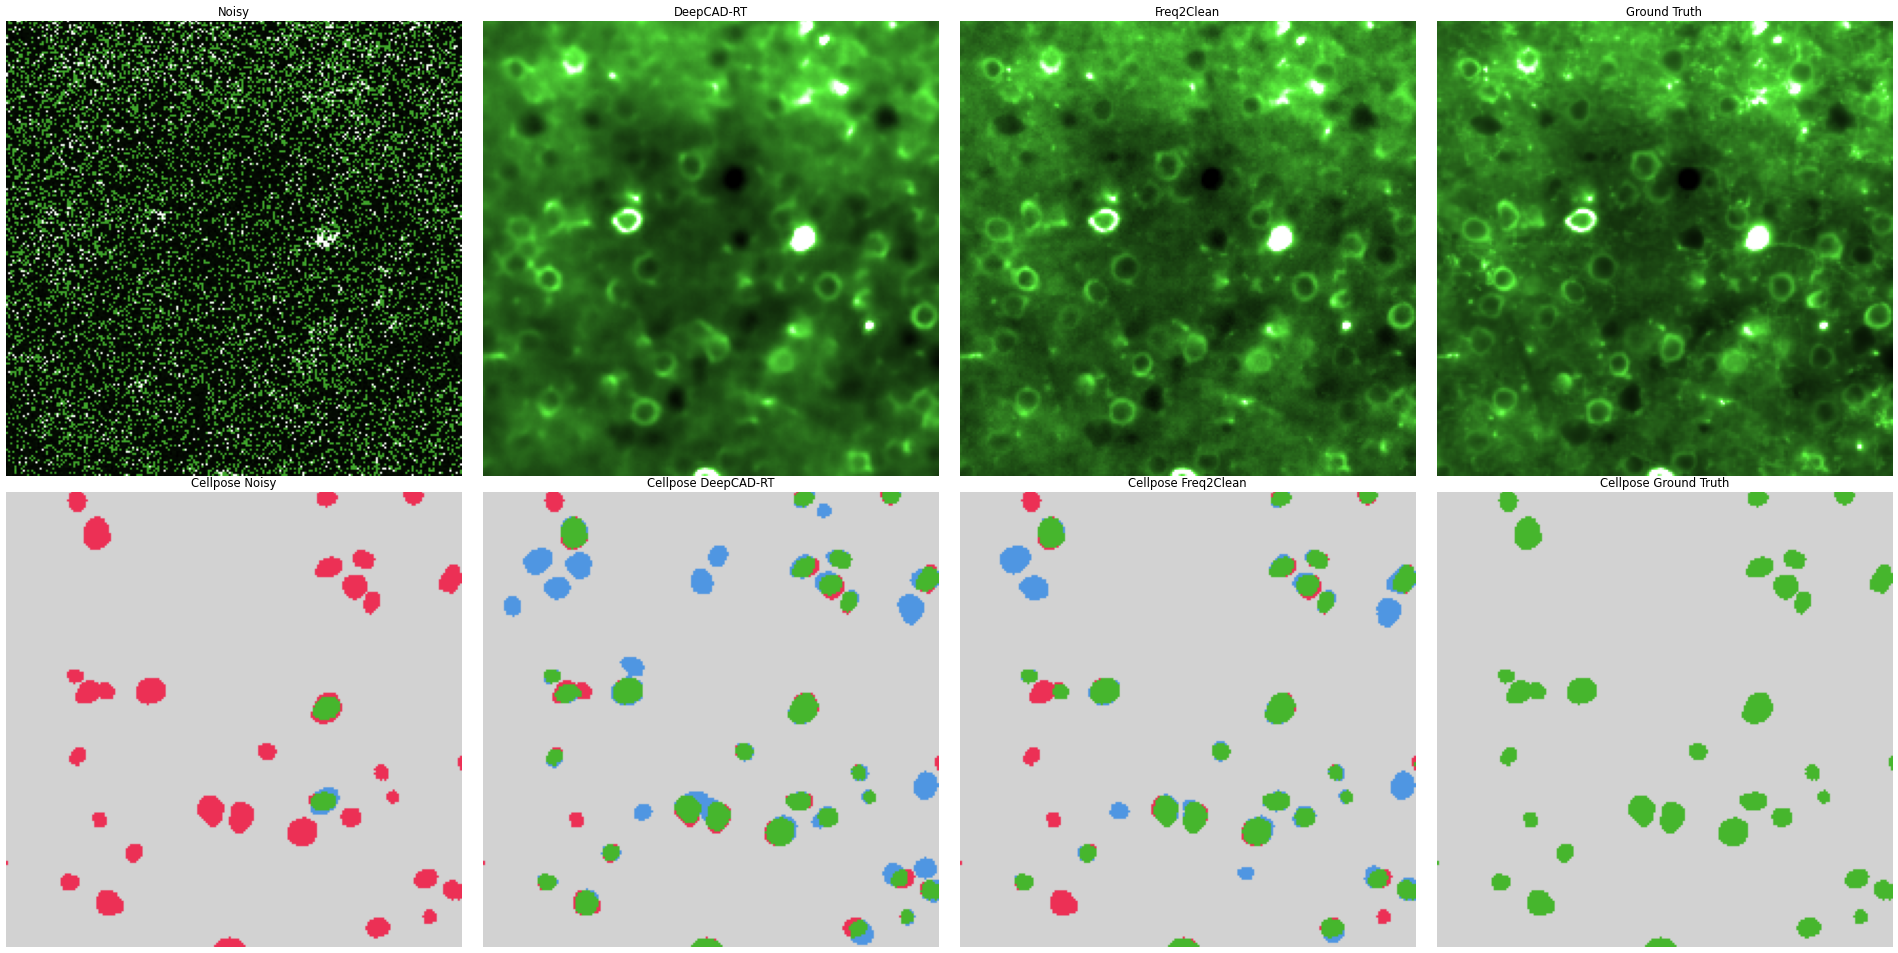

[3]	0.495	0.544	1.0


In [10]:
frames = list(range(0, x.shape[0], x.shape[0] // mask_gt.shape[0]))
idxs = sorted(range(mask_x.shape[0]), key=lambda i: mask_x[i].sum(), reverse=True)
for idx in [3]:
    imshow(
        {
            f"Noisy": norm(x[frames[idx]]),
            f"DeepCAD-RT": norm(deepcad[frames[idx]]),
            f"Freq2Clean": norm(f2c[frames[idx]]),
            f"Ground Truth": norm(gt[frames[idx]]),
            f"Cellpose Noisy": cmask_x[idx],
            f"Cellpose DeepCAD-RT": cmask_dcad[idx],
            f"Cellpose Freq2Clean": cmask_f2c[idx],
            f"Cellpose Ground Truth": cmask_gt[idx],
        },
        size=8,
        cols=4,
        dpi=60,
        zoom=2.25,
        shift=(-128, -128),
        # path=f"stardist_results/stardist_{idx}.png"
    )
    cprint(
        f"[{idx}]",
        round(iou(mask_dcad[idx], mask_gt[idx]), 3),
        round(iou(mask_f2c[idx], mask_gt[idx]), 3),
        round(iou(mask_gt[idx], mask_gt[idx]), 3),
        sep="\t",
    )